**IMPORT LIBRARIES**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

**LOAD DATASET**

In [10]:
df = pd.read_csv(r'D:\airbnb-nyc-analytics\dataset\AB_NYC_2019_data.csv')

**INITAL DATA EXPLORATION**

In [11]:
df.head()

,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365
0,2539,Clean & quiet apt home by the park,2787,John,Brooklyn,Kensington,40.64749,-73.97237,Private room,149,1,9,2018-10-19,0.21,6,365
1,2595,Skylit Midtown Castle,2845,Jennifer,Manhattan,Midtown,40.75362,-73.98377,Entire home/apt,225,1,45,2019-05-21,0.38,2,355
2,3647,THE VILLAGE OF HARLEM....NEW YORK !,4632,Elisabeth,Manhattan,Harlem,40.80902,-73.94190,Private room,150,3,0,NaN,NaN,1,365
3,3831,Cozy Entire Floor of Brownstone,4869,LisaRoxanne,Brooklyn,Clinton Hill,40.68514,-73.95976,Entire home/apt,89,1,270,2019-07-05,4.64,1,194
4,5022,Entire Apt: Spacious Studio/Loft by central park,7192,Laura,Manhattan,East Harlem,40.79851,-73.94399,Entire home/apt,80,10,9,2018-11-19,0.10,1,0


In [12]:
df.columns

Index(['id', 'name', 'host_id', 'host_name', 'neighbourhood_group',
       'neighbourhood', 'latitude', 'longitude', 'room_type', 'price',
       'minimum_nights', 'number_of_reviews', 'last_review',
       'reviews_per_month', 'calculated_host_listings_count',
       'availability_365'],
      dtype='object')

In [13]:
df.dtypes

id                                  int64
name                               object
host_id                             int64
host_name                          object
neighbourhood_group                object
neighbourhood                      object
latitude                          float64
longitude                         float64
room_type                          object
price                               int64
minimum_nights                      int64
number_of_reviews                   int64
last_review                        object
reviews_per_month                 float64
calculated_host_listings_count      int64
availability_365                    int64
dtype: object

In [14]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48895 entries, 0 to 48894
Data columns (total 16 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   id                              48895 non-null  int64  
 1   name                            48879 non-null  object 
 2   host_id                         48895 non-null  int64  
 3   host_name                       48874 non-null  object 
 4   neighbourhood_group             48895 non-null  object 
 5   neighbourhood                   48895 non-null  object 
 6   latitude                        48895 non-null  float64
 7   longitude                       48895 non-null  float64
 8   room_type                       48895 non-null  object 
 9   price                           48895 non-null  int64  
 10  minimum_nights                  48895 non-null  int64  
 11  number_of_reviews               48895 non-null  int64  
 12  last_review                     

In [15]:
df.shape

(48895, 16)

**DATA** **WRANGLING**

In [16]:
#Missing Values
print(df.isnull().sum())

id                                    0
name                                 16
host_id                               0
host_name                            21
neighbourhood_group                   0
neighbourhood                         0
latitude                              0
longitude                             0
room_type                             0
price                                 0
minimum_nights                        0
number_of_reviews                     0
last_review                       10052
reviews_per_month                 10052
calculated_host_listings_count        0
availability_365                      0
dtype: int64


In [17]:
#Fill Missing Values
df['reviews_per_month'] = df['reviews_per_month'].fillna(0)

In [18]:
#Datetime Conversion
df['last_review'] = pd.to_datetime(df['last_review'], errors= 'coerce')

In [19]:
# Drop rows only if important columns are missing
df.dropna(subset=['name', 'host_name'], inplace=True)

In [20]:
#Check Duplicate
df.duplicated().sum()

np.int64(0)

In [ ]:
# Remove duplicates if any
#df.drop_duplicates(inplace=True)

In [ ]:
# Rename Column
#df.rename(columns={ 'last_review': 'last_review_date'}, inplace=True)

In [ ]:
#save processed data
#df.to_csv('AB_NYC_2019_CleanedData.csv', index=False)

**EXPLORATORY DATA ANALYSIS**

In [21]:
df.describe()

,id,host_id,latitude,longitude,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365
count,4.885800e+04,4.885800e+04,48858.000000,48858.000000,48858.000000,48858.000000,48858.000000,38821,48858.000000,48858.000000,48858.000000
mean,1.902335e+07,6.763169e+07,40.728941,-73.952170,152.740309,7.012444,23.273098,2018-10-04 07:23:47.072976128,1.091124,7.148369,112.801425
min,2.539000e+03,2.438000e+03,40.499790,-74.244420,0.000000,1.000000,0.000000,2011-03-28 00:00:00,0.000000,1.000000,0.000000
25%,9.475980e+06,7.818669e+06,40.690090,-73.983070,69.000000,1.000000,1.000000,2018-07-09 00:00:00,0.040000,1.000000,0.000000
50%,1.969114e+07,3.079133e+07,40.723070,-73.955680,106.000000,3.000000,5.000000,2019-05-19 00:00:00,0.370000,1.000000,45.000000
75%,2.915765e+07,1.074344e+08,40.763107,-73.936280,175.000000,5.000000,24.000000,2019-06-23 00:00:00,1.580000,2.000000,227.000000
max,3.648724e+07,2.743213e+08,40.913060,-73.712990,10000.000000,1250.000000,629.000000,2019-07-08 00:00:00,58.500000,327.000000,365.000000
std,1.098289e+07,7.862389e+07,0.054528,0.046159,240.232386,20.019757,44.549898,NaN,1.597270,32.964600,131.610962


CATEGORICAL ANALYSIS

In [22]:
#Borough Distribution
df['neighbourhood_group'].value_counts()

neighbourhood_group
Manhattan        21643
Brooklyn         20089
Queens            5664
Bronx             1089
Staten Island      373
Name: count, dtype: int64

In [23]:
#Room Type Distribution
df['room_type'].value_counts()

room_type
Entire home/apt    25393
Private room       22306
Shared room         1159
Name: count, dtype: int64

NUMERICAL DISTRIBUTION ANALYSIS

In [24]:
#Price Distribution
df['price'].describe()

count    48858.000000
mean       152.740309
std        240.232386
min          0.000000
25%         69.000000
50%        106.000000
75%        175.000000
max      10000.000000
Name: price, dtype: float64

In [25]:
#Review Distribution
df['number_of_reviews'].describe()

count    48858.000000
mean        23.273098
std         44.549898
min          0.000000
25%          1.000000
50%          5.000000
75%         24.000000
max        629.000000
Name: number_of_reviews, dtype: float64

OUTLIER ANALYSIS

<Axes: xlabel='price'>

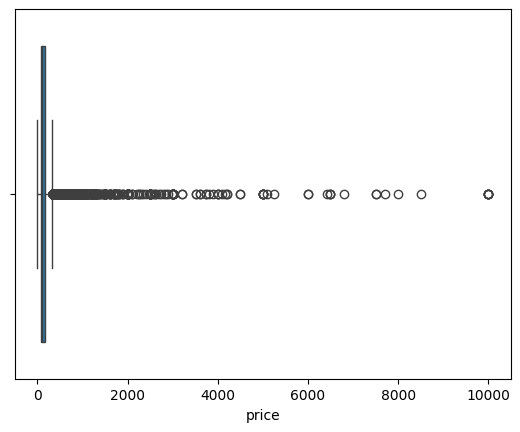

In [26]:
sns.boxplot(x=df['price'])

<Axes: xlabel='price'>

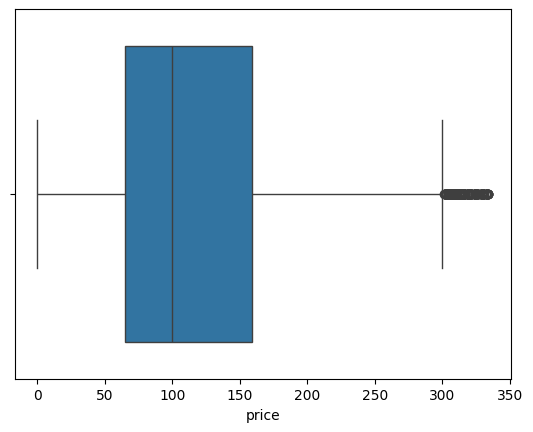

In [27]:
# Remove extreme outliers
q1 = df['price'].quantile(0.25)
q3 = df['price'].quantile(0.75)
iqr = q3 - q1
lower_bound = q1 - 1.5 * iqr
upper_bound = q3 + 1.5 * iqr
df = df[(df['price'] >= lower_bound) & (df['price'] <= upper_bound)]
sns.boxplot(x=df['price'])

RELATIONSHIP ANALYSIS

In [28]:
#Average price by borough
df.groupby('neighbourhood_group')['price'].mean()

neighbourhood_group
Bronx             77.318352
Brooklyn         105.713454
Manhattan        145.942891
Queens            88.919317
Staten Island     89.235616
Name: price, dtype: float64

In [29]:
#Average price by room type
df.groupby('room_type')['price'].mean()

room_type
Entire home/apt    162.517125
Private room        79.022297
Shared room         59.231310
Name: price, dtype: float64

In [30]:
#Reviews by borough
df.groupby('neighbourhood_group')['number_of_reviews'].mean()

neighbourhood_group
Bronx            26.355805
Brooklyn         24.512165
Manhattan        21.945713
Queens           27.973226
Staten Island    31.605479
Name: number_of_reviews, dtype: float64

CORRELATION ANALYSIS

In [31]:
numeric_df = df.select_dtypes(include='number')

numeric_df.corr()

,id,host_id,latitude,longitude,price,minimum_nights,number_of_reviews,reviews_per_month,calculated_host_listings_count,availability_365
id,1.000000,0.581393,-0.008027,0.101547,-0.018063,-0.013829,-0.320693,0.178793,0.125551,0.073377
host_id,0.581393,1.000000,0.015943,0.144474,-0.034668,-0.017937,-0.136711,0.208139,0.147280,0.193928
latitude,-0.008027,0.015943,1.000000,0.091374,0.068766,0.025985,-0.012324,-0.017930,0.021455,-0.017249
longitude,0.101547,0.144474,0.091374,1.000000,-0.306978,-0.064215,0.053944,0.140833,-0.107684,0.096995
price,-0.018063,-0.034668,0.068766,-0.306978,1.000000,0.031472,-0.027675,-0.047422,0.174450,0.066710
minimum_nights,-0.013829,-0.017937,0.025985,-0.064215,0.031472,1.000000,-0.082934,-0.127869,0.133638,0.146438
number_of_reviews,-0.320693,-0.136711,-0.012324,0.053944,-0.027675,-0.082934,1.000000,0.593655,-0.070557,0.183409
reviews_per_month,0.178793,0.208139,-0.017930,0.140833,-0.047422,-0.127869,0.593655,1.000000,-0.051093,0.171450
calculated_host_listings_count,0.125551,0.147280,0.021455,-0.107684,0.174450,0.133638,-0.070557,-0.051093,1.000000,0.225704
availability_365,0.073377,0.193928,-0.017249,0.096995,0.066710,0.146438,0.183409,0.171450,0.225704,1.000000


**FEATURE ENGINEERING**

In [32]:
#PRICE CATEGORY
bins = [0, 100, 200, 500, 1000]
labels = ['Budget', 'Moderate', 'Premium', 'Luxury']

df['price_category'] = pd.cut(
    df['price'],
    bins=bins,
    labels=labels
)

In [33]:
#AVAILABILITY CATRGORY
bins = [0, 30, 60, 90, 120]
labels = ['Short', 'Medium', 'Long', 'Very Long']

df['availability_category'] = pd.cut(
    df['availability_365'],
    bins=bins,
    labels=labels
)

In [34]:
#REVENUE ESTIMATION
df['estimated_revenue'] = df['price'] * df['minimum_nights']

**KPI - KEY PERFORMANCE INDICATOR**

FINANCIAL KPIs

In [35]:
avg_price = df['price'].mean()

In [36]:
total_listings = df['id'].count()

In [37]:
total_hosts = df['host_id'].nunique()

In [38]:
avg_reviews = df['number_of_reviews'].mean()

In [39]:
avg_availability = df['availability_365'].mean()

FINANCIAL KPIs

In [40]:
avg_revenue = df['estimated_revenue'].mean()

In [41]:
revenue_by_borough = df.groupby('neighbourhood_group')['estimated_revenue'].mean()

OPERATIONAL KPIs

In [42]:
#OPERATIONAL KPIs
host_activity = df.groupby('host_name')['id'].count().sort_values(ascending=False)

In [43]:
popular_neighbourhoods = (
    df.groupby('neighbourhood')['number_of_reviews']
    .sum()
    .sort_values(ascending=False)
)
popular_neighbourhoods

neighbourhood
Bedford-Stuyvesant            108773
Williamsburg                   82399
Harlem                         74735
Bushwick                       52106
Hell's Kitchen                 47202
                               ...  
West Farms                         7
Breezy Point                       5
Sea Gate                           4
Bay Terrace, Staten Island         3
New Dorp                           0
Name: number_of_reviews, Length: 219, dtype: int64

In [44]:
bins = [-1, 90, 180, 365]
labels = ['Rarely Available', 'Part-time', 'Year-round']

# Create the new binned column
df['availability_type'] = pd.cut(df['availability_365'], bins=bins, labels=labels)

# Check the distribution
print(df['availability_type'].value_counts())

availability_type
Rarely Available    27952
Year-round          13020
Part-time            4915
Name: count, dtype: int64


**VISUALIZATION**

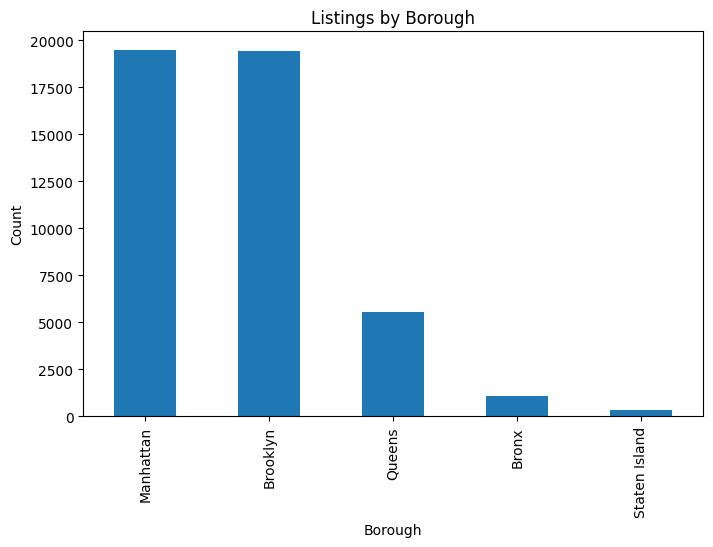

In [45]:
#Listings by Borough
borough_counts = df['neighbourhood_group'].value_counts()

plt.figure(figsize=(8,5))
borough_counts.plot(kind='bar')
plt.title('Listings by Borough')
plt.xlabel('Borough')
plt.ylabel('Count')
plt.show()

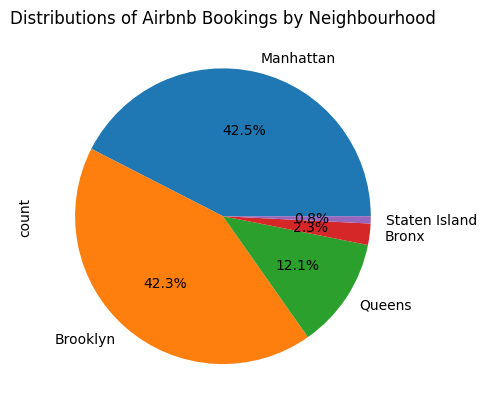

In [46]:
df['neighbourhood_group'].value_counts().plot(kind='pie', autopct='%1.1f%%')

plt.title('Distributions of Airbnb Bookings by Neighbourhood')

plt.show()

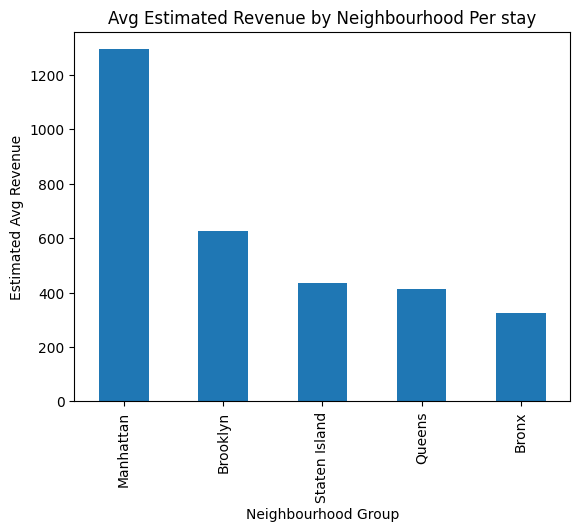

In [47]:
#Average revenue by Borourgh
avg_revenue = df.groupby('neighbourhood_group')['estimated_revenue'].mean().sort_values(ascending=False)
avg_revenue.plot(kind='bar')

plt.title('Avg Estimated Revenue by Neighbourhood Per stay')
plt.xlabel('Neighbourhood Group')
plt.ylabel('Estimated Avg Revenue')

plt.show()

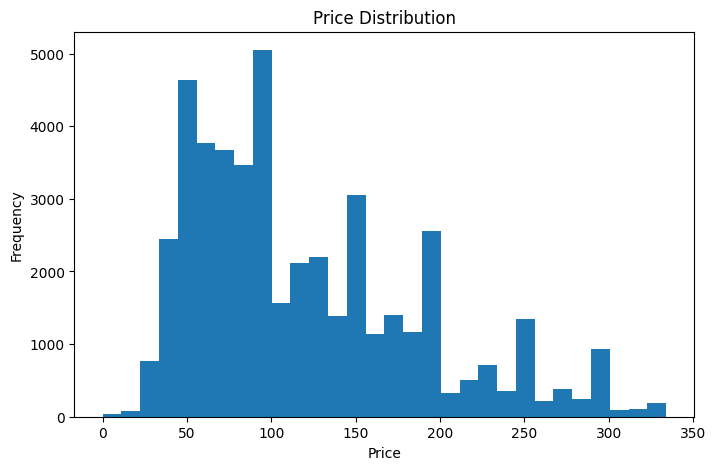

In [48]:
#Price Distribution
plt.figure(figsize=(8,5))
plt.hist(df['price'], bins=30)
plt.title('Price Distribution')
plt.xlabel('Price')
plt.ylabel('Frequency')
plt.show()

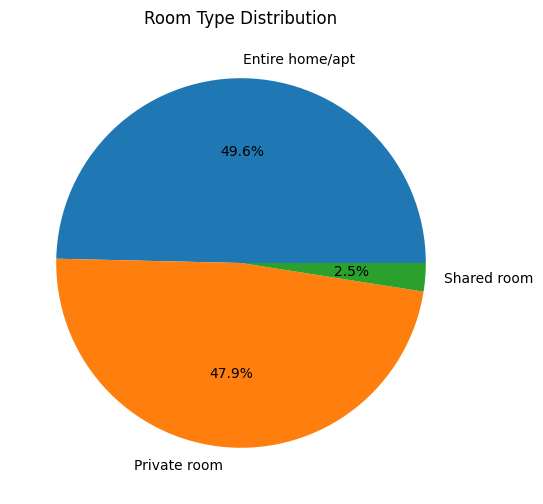

In [49]:
#Room Type Share
room_counts = df['room_type'].value_counts()

plt.figure(figsize=(6,6))
plt.pie(room_counts, labels=room_counts.index, autopct='%1.1f%%')
plt.title('Room Type Distribution')
plt.show()

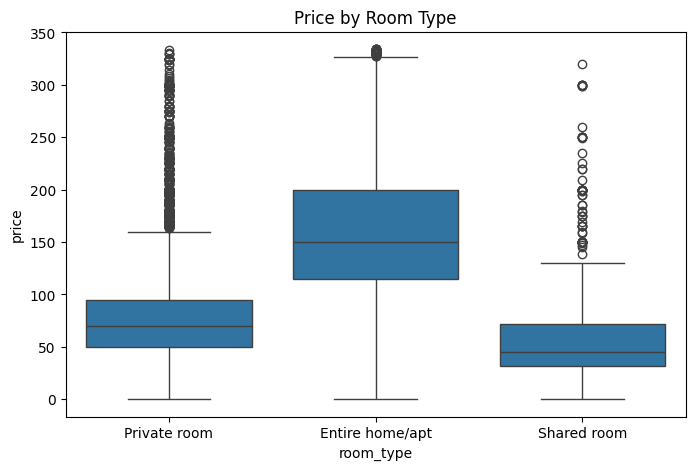

In [50]:
#Price by Room Type
plt.figure(figsize=(8,5))
sns.boxplot(x='room_type', y='price', data=df)
plt.title('Price by Room Type')
plt.show()

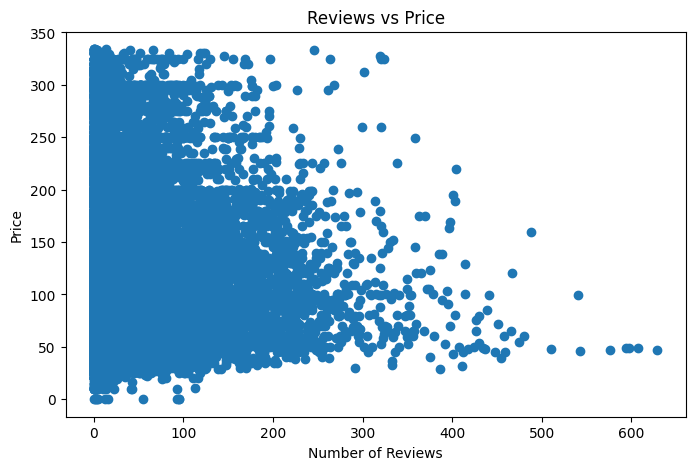

In [51]:
#Reviews vs Price
plt.figure(figsize=(8,5))
plt.scatter(df['number_of_reviews'], df['price'])
plt.title('Reviews vs Price')
plt.xlabel('Number of Reviews')
plt.ylabel('Price')
plt.show()

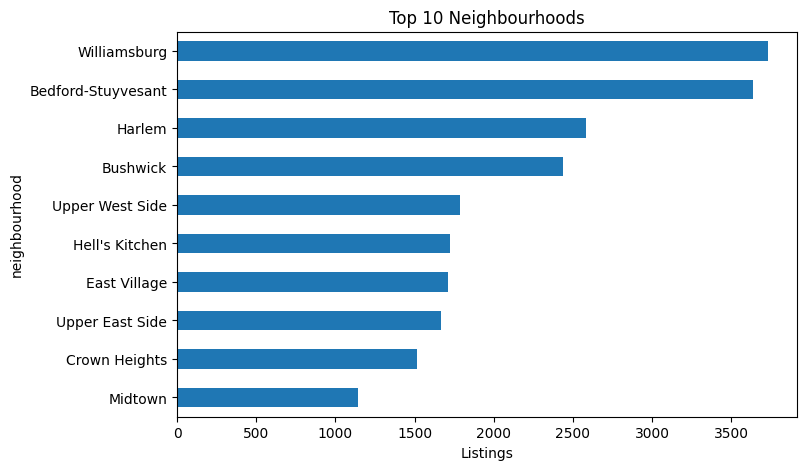

In [52]:
#Top 10 Neighbourhoods
top_neighbourhoods = df['neighbourhood'].value_counts().head(10)

plt.figure(figsize=(8,5))
top_neighbourhoods.sort_values().plot(kind='barh')
plt.title('Top 10 Neighbourhoods')
plt.xlabel('Listings')
plt.show()

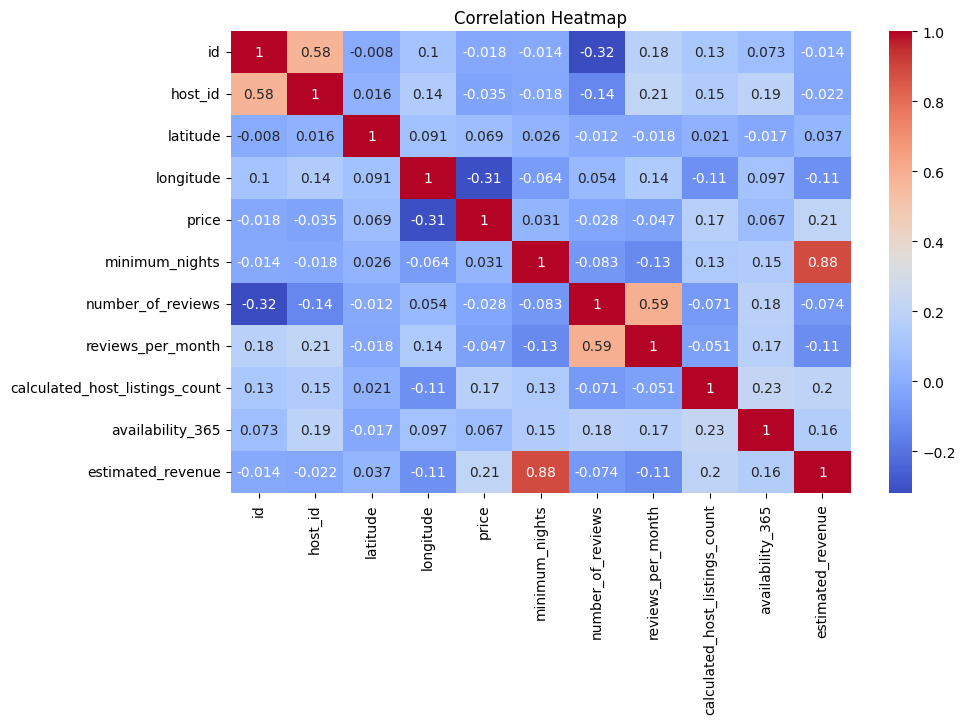

In [53]:
#Correlation Heatmap
numeric_df = df.select_dtypes(include='number')

plt.figure(figsize=(10,6))
sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()

C:\Users\tamiz\AppData\Local\Temp\ipykernel_14116\20353509.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby(['availability_type', 'neighbourhood_group'])


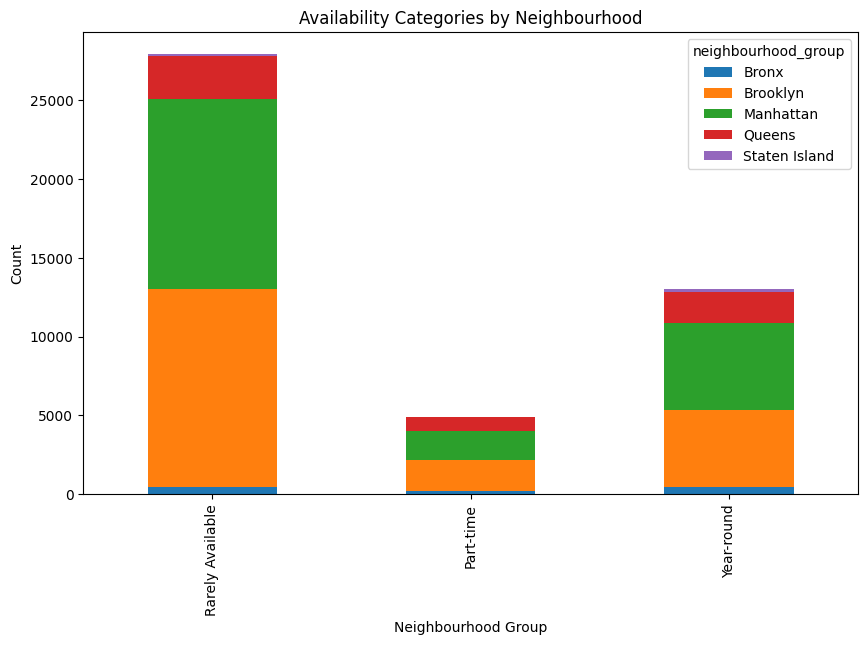

In [54]:
# Count each availability category by neighbourhood
stacked_data = (
    df.groupby(['availability_type', 'neighbourhood_group'])
      .size()
      .unstack()
)

# Create stacked bar chart
stacked_data.plot(kind='bar', stacked=True, figsize=(10,6))

plt.title('Availability Categories by Neighbourhood')
plt.xlabel('Neighbourhood Group')
plt.ylabel('Count')

plt.show()

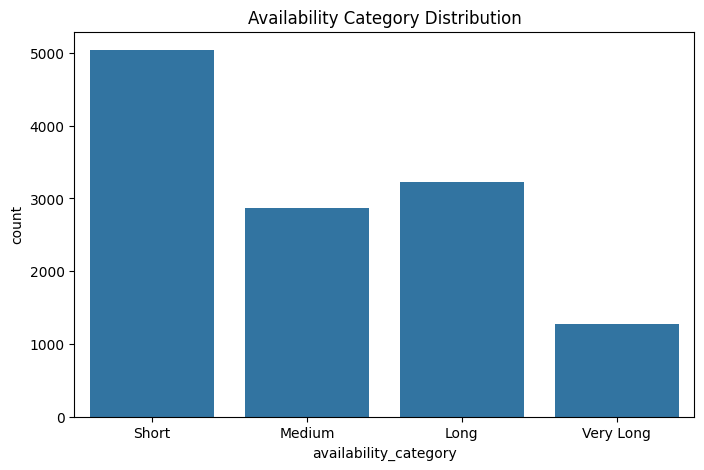

In [55]:
  #Availability Category
plt.figure(figsize=(8,5))
sns.countplot(x='availability_category', data=df)
plt.title('Availability Category Distribution')
plt.show()

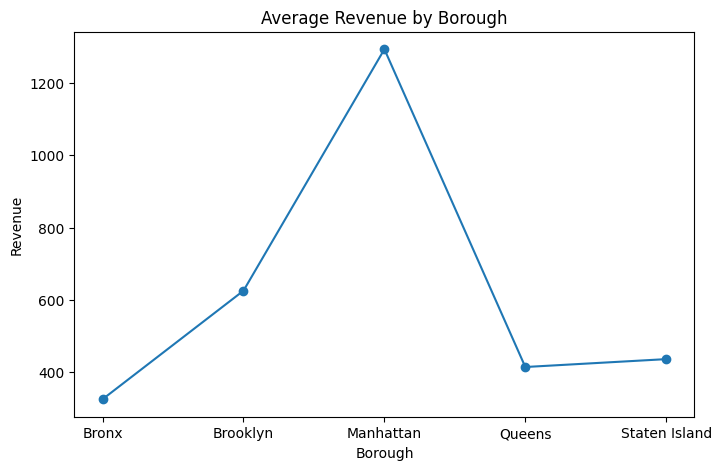

In [56]:
#Borough Revenue
borough_revenue = df.groupby('neighbourhood_group')['estimated_revenue'].mean()

plt.figure(figsize=(8,5))
plt.plot(borough_revenue.index, borough_revenue.values, marker='o')
plt.title('Average Revenue by Borough')
plt.xlabel('Borough')
plt.ylabel('Revenue')
plt.show()

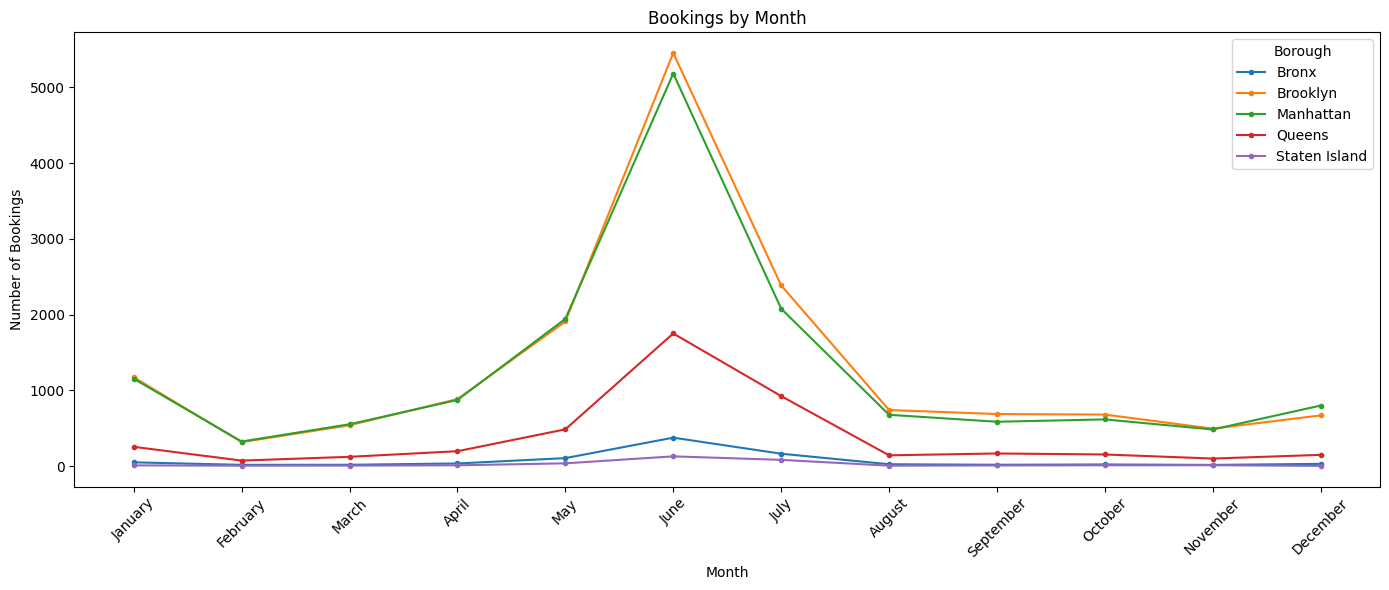

In [58]:
#Monthly Bookings over time by Borough

# Filter boroughs
boroughs = ['Manhattan', 'Brooklyn', 'Queens','Bronx', 'Staten Island']
df_boroughs = df[df['neighbourhood_group'].isin(boroughs)].copy()

# Convert to datetime
df_boroughs['review_date'] = pd.to_datetime(
    df_boroughs['last_review'],
    errors='coerce'
)

# Remove invalid dates
df_boroughs = df_boroughs.dropna(subset=['review_date'])

# Extract month names
df_boroughs['month'] = df_boroughs['review_date'].dt.month_name()

# Count bookings by month + borough
booking_counts = (
    df_boroughs.groupby(['month', 'neighbourhood_group'])
                .size()
                .unstack(fill_value=0)
)

# Correct month order
month_order = [
    'January', 'February', 'March', 'April',
    'May', 'June', 'July', 'August',
    'September', 'October', 'November', 'December'
]

booking_counts = booking_counts.reindex(month_order)

# Plot
fig, ax = plt.subplots(figsize=(14,6))

for col in booking_counts.columns:
    ax.plot(
        booking_counts.index,
        booking_counts[col],
        marker='o',
        markersize=3,
        label=col
    )

ax.set_title('Bookings by Month')
ax.set_xlabel('Month')
ax.set_ylabel('Number of Bookings')

ax.legend(title='Borough')

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()